# Module 4, Class 2: Logistic Regression

**Student:** Firdavs Boliev  
**Dataset:** Telco Customer Churn

This notebook trains a logistic regression model and compares decision thresholds for churn prediction.


## 0. Setup

In [1]:
# Import the libraries needed for preprocessing, modeling, metrics, and plots.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")


Setup complete.


## 1. Load and Preprocess Data

In [2]:
# Load the Telco data, clean a few repeated labels, and split features from the target.
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Standardize service columns
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in replace_cols:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Features and target
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Shape: {X.shape}")
print(f"Churn rate: {y.mean():.2%}")


Shape: (7043, 19)
Churn rate: 26.54%


In [3]:
# Build preprocessing steps for numeric and categorical columns, then split the data.
# Build preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, cat_cols)
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (5634, 19), Test: (1409, 19)


## 2. Train Logistic Regression

In [4]:
# Train logistic regression and get both class predictions and churn probabilities.
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Accuracy: 0.8055

## 3. Confusion Matrix

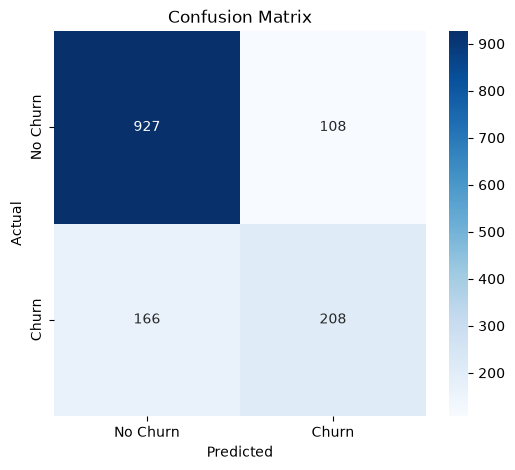

True Negatives:  927
False Positives: 108
False Negatives: 166
True Positives:  208


In [5]:
# Build a confusion matrix to count correct and incorrect predictions.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")


## 4. Classification Metrics

In [6]:
# Print the classification report and ROC-AUC score.
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


Full Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8421


In [7]:
# Collect the main classification metrics in one small dictionary.
# Individual metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

for name, val in metrics.items():
    print(f"{name:>10}: {val:.4f}")


  Accuracy: 0.8055
 Precision: 0.6582
    Recall: 0.5561
        F1: 0.6029
   ROC-AUC: 0.8421


## 5. ROC Curve

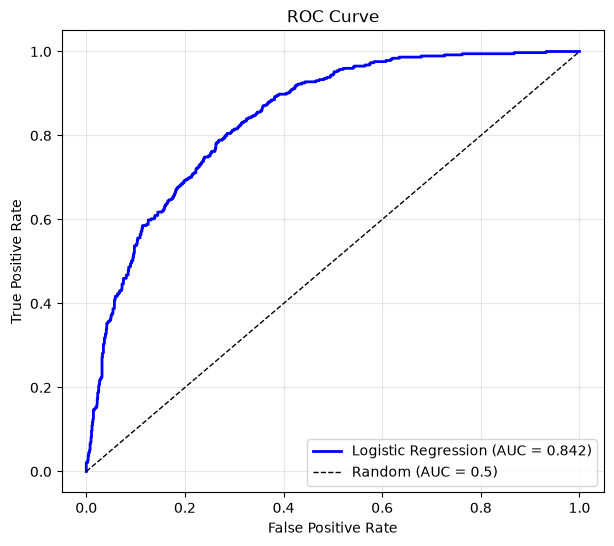

In [8]:
# Plot the ROC curve to show how the model performs across thresholds.
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 6. Coefficient Interpretation (Odds Ratios)

In logistic regression, exp(coefficient) gives the odds ratio: how much the odds of churn multiply when the feature increases by 1 unit.

In [9]:
# Read logistic regression coefficients and odds ratios after preprocessing.
# Get feature names after encoding
ohe = pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = numeric_cols + cat_feature_names

# Coefficients and odds ratios
coefs = pipe.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefs,
    'Odds Ratio': np.exp(coefs)
}).sort_values('Coefficient', ascending=False)

print("Top 10 features increasing churn:")
print(coef_df.head(10).to_string(index=False))
print()
print("Top 10 features decreasing churn:")
print(coef_df.tail(10).to_string(index=False))


Top 10 features increasing churn:
                       Feature  Coefficient  Odds Ratio
   InternetService_Fiber optic     1.032414    2.807836
                  TotalCharges     0.492870    1.637008
PaymentMethod_Electronic check     0.390624    1.477902
          PaperlessBilling_Yes     0.373868    1.453345
             MultipleLines_Yes     0.333192    1.395416
           StreamingMovies_Yes     0.316507    1.372326
               StreamingTV_Yes     0.314302    1.369303
    PaymentMethod_Mailed check     0.077175    1.080231
                 SeniorCitizen     0.054058    1.055546
                   Partner_Yes     0.021941    1.022183

Top 10 features decreasing churn:
           Feature  Coefficient  Odds Ratio
  OnlineBackup_Yes    -0.127669    0.880145
    Dependents_Yes    -0.228734    0.795540
    MonthlyCharges    -0.276811    0.758198
   TechSupport_Yes    -0.328675    0.719877
  PhoneService_Yes    -0.373776    0.688131
OnlineSecurity_Yes    -0.375468    0.686968
 Contra

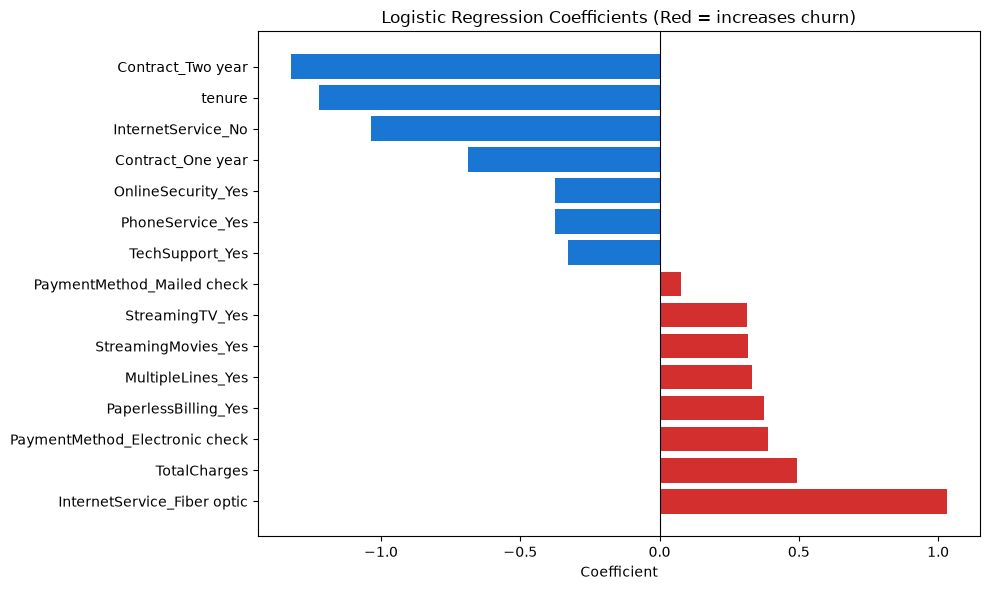

In [10]:
# Plot the strongest positive and negative coefficients.
# Visualize top features
top_n = 15
top_features = pd.concat([coef_df.head(top_n // 2 + 1), coef_df.tail(top_n // 2)])

plt.figure(figsize=(10, 6))
colors = ['#d32f2f' if c > 0 else '#1976d2' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient')
plt.title('Logistic Regression Coefficients (Red = increases churn)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## 7. Threshold Adjustment

By default, logistic regression uses a threshold of 0.5 to classify. Lowering the threshold catches more churners (higher recall) but also more false positives (lower precision).

**Your task:**
1. Classify using thresholds 0.3, 0.4, and 0.5
2. Compute precision, recall, and F1 for each
3. Build a comparison table
4. Write a brief conclusion: which threshold would you choose for a churn prevention campaign and why?

In [11]:
# Compare precision, recall, and F1 at three churn probability thresholds.
thresholds_to_test = [0.3, 0.4, 0.5]
threshold_results = []

for threshold in thresholds_to_test:
    # Convert probabilities into 0/1 predictions using the current threshold.
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold),
    })

# Show the comparison table.
threshold_df = pd.DataFrame(threshold_results).round(4)
threshold_df


,Threshold,Precision,Recall,F1
0,0.3,0.5203,0.7540,0.6157
1,0.4,0.5718,0.6711,0.6175
2,0.5,0.6582,0.5561,0.6029


### Threshold Conclusion

I would choose the **0.4 threshold** for this churn prevention campaign. It keeps recall high enough to catch many churn customers, but it has better precision than 0.3, so the company does not contact too many customers who are unlikely to churn. If the company cared only about catching as many churners as possible, 0.3 would also be reasonable.



---
## Summary

| Concept | Details |
|---------|---------|
| Logistic Regression | Predicts probability of class membership |
| Confusion Matrix | TP, FP, TN, FN breakdown |
| Precision | Of predicted positives, how many are correct |
| Recall | Of actual positives, how many were caught |
| F1 | Harmonic mean of precision and recall |
| ROC-AUC | Area under ROC curve (1.0 = perfect, 0.5 = random) |
| Odds Ratio | exp(coef): multiplicative change in odds per unit increase |
| Threshold | Lower = more recall, less precision |